# 分析问题

## 层次分析法

In [1]:
import numpy as np
import warnings


class AHP:
    def __init__(self, criteria, factors):
        self.RI = (0, 0, 0.58, 0.9, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49)
        self.criteria = criteria
        self.factors = factors
        self.n_criteria = criteria.shape[0]
        self.n_factors = factors.shape[0]
        
    def get_weights(self, compare_matrix):
        compare_matrix = np.array(compare_matrix)
        n, m = compare_matrix.shape
        assert n == m, "The matrix must be square"
        for i, j in zip(range(n), range(m)):
            if np.abs(compare_matrix[i, j] * compare_matrix[j, i] - 1) > 1e-7:
                raise ValueError("The matrix must be a similarity matrix")
        
        eigen_values, eigen_vectors = np.linalg.eig(compare_matrix)
        max_eigen_index = np.argmax(eigen_values)
        max_eigen = eigen_values[max_eigen_index].real
        max_eigen_vector = eigen_vectors[:, max_eigen_index].real
        weight = max_eigen_vector / max_eigen_vector.sum()   # 归一化
        
        if n > 9:
            CR = None
            CI = None
            warnings.warn("The number of criteria or factors is too large, the CR value may be inaccurate")
        else:
            CI = (max_eigen - n) / (n - 1)
            CR = CI / self.RI[n]
        return max_eigen, CR, CI, weight
    
    def run(self):
        max_eigen, CR, _, weight = self.get_weights(self.criteria)
        print("中间层：最大特征值={:<5f}, CR={:<5f}, 检验{}通过".format(max_eigen, CR, "不" if CR >= 0.1 else ""))
        print(f"中间层权重={weight}\n")
        
        max_eigens, CIs, weights, = [], [], []
        for i, k in enumerate(self.factors):
            max_eigen, CR, CI, temp_weight = self.get_weights(i)      
            max_eigens.append(max_eigen)
            CIs.append(CI)
            weights.append(temp_weight)
            print("因素 {}：最大特征值={:<5f}, CR={:<5f}, 检验{}通过".format(k, max_eigen, CR, "不" if CR >= 0.1 else ""))
            print(f"权重={temp_weight}\n")
        
        return max_eigens, CIs, weights, weight
    
    def get_result(self):
        max_eigens, CIs, weights, weight = self.run()
        W = []
        for i in range(self.n_factors):
            temp = []
            for j in weights:
                temp.append(j[i])
            W.append(temp)
        W = np.array(W)
        result = np.dot(W, weight)
        return np.argmax(result)

## TOPSIS 法

In [2]:
class TOPSIS:
    def __init__(self, data, weight, flags, section_info):
        self.data = data.T
        self.weight = weight
        self.flags = flags
        self.section_info = section_info
        self.c_star = []
        self.c0 = []
        self.s_star = []
        self.s0 = []
        self.f = []
    
    def section_process(self, index):
        assert len(self.section_info[index]) == 4, "The section information must be a list of 4 elements"
        a_min, a0, a_star, a_max = self.section_info[index]
        for i, a in enumerate(self.data[index]):
            if a_min <= a <= a0:
                self.data[index][i] = 1 - (a0 - a) / (a0 - a_min)
            elif a0 < a <= a_star:
                self.data[index][i] = 1
            elif a_star < a <= a_max:
                self.data[index][i] = 1 - (a - a_star) / (a_max - a_star)
            else:
                self.data[index][i] = 0
        return self.data
    
    def normalize(self):
        for i, flag in enumerate(self.flags):
            if flag == 0:
                self.section_process(i)
        sum_sigma = []
        for i in self.data:
            temp = 0
            for j in i:
                temp += j ** 2
            sum_sigma.append(temp ** 0.5)
        for i, j in enumerate(self.data):
            for k, a in enumerate(j):
                b = a / sum_sigma[i]
                self.data[i][k] = b
        return self.data
    
    def apply_weight(self):
        for i, j in enumerate(self.data):
            for k in range(len(j)):
                self.data[i][k] *= self.weight[i]
        return self.data
    
    def positive_negative(self):
        for i, j in enumerate(self.data):
            max_c = max(j)
            min_c = min(j)
            if self.flags[i] == 1 or self.flags[i] == 0:
                self.c_star.append(max_c)
                self.c0.append(min_c)
            elif self.flags[i] == -1:
                self.c_star.append(min_c)
                self.c0.append(max_c)
    
    def distance(self):
        self.data = self.data.T
        for i in self.data:
            sum1 = 0
            sum2 = 0
            for j, c in enumerate(i):
                sum1 += (c - self.c_star[j]) ** 2
                sum2 += (c - self.c0[j]) ** 2
            self.s_star.append(sum1 ** 0.5)
            self.s0.append(sum2 ** 0.5)
    
    def get_result(self):
        self.normalize()
        self.apply_weight()
        self.positive_negative()
        self.distance()
        for i, j in zip(self.s_star, self.s0):
            self.f.append(i / (i + j))
        self.f = np.array(self.f)
        return np.argsort(self.f)

In [3]:
data = np.array([
    [0.1, 5, 5000, 4.7],
    [0.2, 6, 6000, 5.6],
    [0.4, 7, 7000, 6.7],
    [0.9, 10, 10000, 2.3],
    [1.2, 2, 400, 1.8]
])
weight = np.array([0.2, 0.3, 0.4, 0.1])
flags = [1, 0, 1, -1]
section_info = np.array([
    [0, 0, 0, 0],
    [2, 5, 6, 12],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
])
topsis = TOPSIS(data, weight, flags, section_info)
print(topsis.get_result())

[3 2 1 0 4]


## K-means 聚类分析

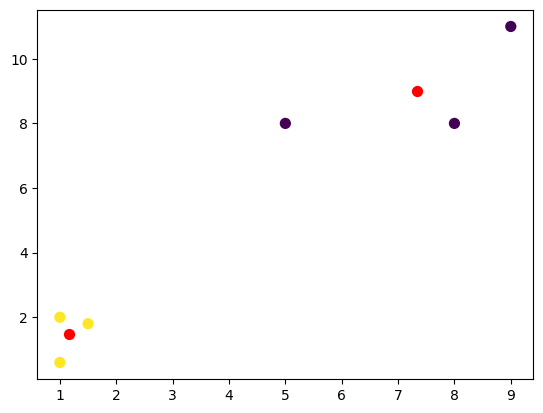

In [4]:
# k-means 算法
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

x = np.array([[1, 2], [1.5, 1.8], [5, 8], [8, 8], [1, 0.6], [9, 11]])
kmeans = KMeans(n_clusters=2)
kmeans.fit(x)
y_kmeans = kmeans.predict(x)

plt.scatter(x[:, 0], x[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=50)
plt.show()

## 主成分分析

(array([0.55311753, 0.58946436, 0.35040603, 0.70076072, 0.55170561]), np.float64(0.5771598345226391))
(np.float64(97.86671662682286), np.float64(1.4552468446812505e-16))
[0.57247824 0.38677374]
[4.29358678 2.90080302]


D:\codes\Modelization\venv\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


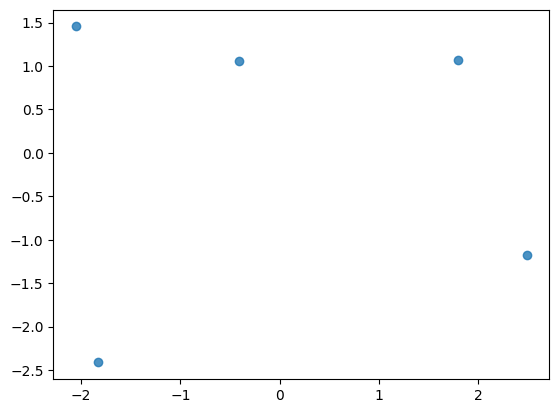

In [24]:
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

X = np.array([
    [84, 65, 61, 72, 79, 81],
    [64, 77, 77, 76, 55, 70],
    [65, 67, 63, 49, 57, 67],
    [74, 80, 69, 75, 63, 74],
    [84, 74, 70, 80, 74, 82],
])
X = (X - X.mean(axis=0)) / X.std(axis=0)
print(calculate_kmo(X.T))     # return: 
print(calculate_bartlett_sphericity(X.T))   # return: 卡方值、p值
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)
print(pca.explained_variance_ratio_)    # 方差贡献率
print(pca.explained_variance_)          # 方差值
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.8)
plt.show()